<a href="https://colab.research.google.com/github/lrimaclab26/Test/blob/main/Proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projecto final

In [1]:
!pip -q install folium "dash>=2.11" plotly seaborn beautifulsoup4
import requests, time, datetime, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
pd.set_option('display.max_columns', None)
BASE = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 38.2 MB/s eta 0:00:00


## 1. Recolección de datos – API REST de SpaceX (lab *Data Collection API*)


In [2]:
# Funciones auxiliares: usan los IDs del lanzamiento para consultar cohete, sitio, payload y core
_cache = {}
def safe_get(url, tries=3):
    if url in _cache: return _cache[url]
    for _ in range(tries):
        try:
            r = requests.get(url, timeout=20)
            if r.status_code == 200:
                _cache[url] = r.json(); return _cache[url]
        except Exception:
            pass
        time.sleep(1)
    raise RuntimeError(f'La API no respondió JSON válido para {url}')

def getBoosterVersion(data):
    for x in data['rocket']:
        if x:
            BoosterVersion.append(safe_get('https://api.spacexdata.com/v4/rockets/'+str(x))['name'])

def getLaunchSite(data):
    for x in data['launchpad']:
        if x:
            r = safe_get('https://api.spacexdata.com/v4/launchpads/'+str(x))
            Longitude.append(r['longitude']); Latitude.append(r['latitude']); LaunchSite.append(r['name'])

def getPayloadData(data):
    for load in data['payloads']:
        if load:
            r = safe_get('https://api.spacexdata.com/v4/payloads/'+load)
            PayloadMass.append(r['mass_kg']); Orbit.append(r['orbit'])

def getCoreData(data):
    for core in data['cores']:
        if core['core'] != None:
            r = safe_get('https://api.spacexdata.com/v4/cores/'+core['core'])
            Block.append(r['block']); ReusedCount.append(r['reuse_count']); Serial.append(r['serial'])
        else:
            Block.append(None); ReusedCount.append(None); Serial.append(None)
        Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))
        Flights.append(core['flight']); GridFins.append(core['gridfins'])
        Reused.append(core['reused']); Legs.append(core['legs']); LandingPad.append(core['landpad'])

### Task 1 – Petición GET y parseo del JSON

In [3]:
static_json_url = BASE + 'datasets/API_call_spacex_api.json'
response = requests.get(static_json_url)
print('Status code:', response.status_code)          # esperado: 200
data = pd.json_normalize(response.json())
data.head()

Status code: 200


,static_fire_date_utc,static_fire_date_unix,tbd,net,window,rocket,success,details,crew,ships,capsules,payloads,launchpad,auto_update,failures,flight_number,name,date_utc,date_unix,date_local,date_precision,upcoming,cores,id,fairings.reused,fairings.recovery_attempt,fairings.recovered,fairings.ships,links.patch.small,links.patch.large,links.reddit.campaign,links.reddit.launch,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Engine failure at 33 seconds and loss of vehicle,[],[],[],[5eb0e4b5b6c3bb0006eeb1e1],5e9e4502f5090995de566f86,True,"[{'time': 33, 'altitude': None, 'reason': 'mer...",1,FalconSat,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight'...",5eb87cd9ffd86e000604b32a,False,False,False,[],https://images2.imgbox.com/3c/0e/T8iJcSN3_o.png,https://images2.imgbox.com/40/e3/GypSkayF_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-fa...,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Successful first stage burn and transition to ...,[],[],[],[5eb0e4b6b6c3bb0006eeb1e2],5e9e4502f5090995de566f86,True,"[{'time': 301, 'altitude': 289, 'reason': 'har...",2,DemoSat,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight'...",5eb87cdaffd86e000604b32b,False,False,False,[],https://images2.imgbox.com/4f/e3/I0lkuJ2e_o.png,https://images2.imgbox.com/be/e7/iNqsqVYM_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-roc...,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Residual stage 1 thrust led to collision betwe...,[],[],[],"[5eb0e4b6b6c3bb0006eeb1e3, 5eb0e4b6b6c3bb0006e...",5e9e4502f5090995de566f86,True,"[{'time': 140, 'altitude': 35, 'reason': 'resi...",3,Trailblazer,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight'...",5eb87cdbffd86e000604b32c,False,False,False,[],https://images2.imgbox.com/3d/86/cnu0pan8_o.png,https://images2.imgbox.com/4b/bd/d8UxLh4q_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1...,https://en.wikipedia.org/wiki/Trailblazer_(sat...,NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,True,Ratsat was carried to orbit on the first succe...,[],[],[],[5eb0e4b7b6c3bb0006eeb1e5],5e9e4502f5090995de566f86,True,[],4,RatSat,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight'...",5eb87cdbffd86e000604b32d,False,False,False,[],https://images2.imgbox.com/e9/c9/T8CfiSYb_o.png,https://images2.imgbox.com/e0/a7/FNjvKlXW_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=dLQ2tZEH6G0,dLQ2tZEH6G0,https://en.wikipedia.org/wiki/Ratsat,https://en.wikipedia.org/wiki/Ratsat,NaN
4,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,True,None,[],[],[],[5eb0e4b7b6c3bb0006eeb1e6],5e9e4502f5090995de566f86,True,[],5,RazakSat,2009-07-13T03:35:00.000Z,1247456100,2009-07-13T15:35:00+12:00,hour,False,"[{'core': '5e9e289ef359184f103b2627', 'flight'...",5eb87cdcffd86e000604b32e,False,False,False,[],https://images2.imgbox.com/a7/ba/NBZSw3Ho_o.png,https://images2.imgbox.com/8d/fc/0qdZMWWx_o.png,None,None,None,None,[],[],http://www.spacex.com/press/2012/12/19/spacexs...,https://www.youtube.com/watch?v=yTaIDooc8Og,yTaIDooc8Og,http://www.spacex.com/news/2013/02/12/falcon-1...,https://en.wikipedia.org/wiki/RazakSAT,NaN


In [4]:
# Subconjunto de columnas útiles + filtros del lab
data = data[['rocket','payloads','launchpad','cores','flight_number','date_utc']]
data = data[data['cores'].map(len)==1]          # solo 1 core (sin Falcon Heavy)
data = data[data['payloads'].map(len)==1]       # solo 1 payload
data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])
data['date'] = pd.to_datetime(data['date_utc']).dt.date
data = data[data['date'] <= datetime.date(2020, 11, 13)]
print(data.shape)

(94, 7)


In [5]:
BoosterVersion=[]; PayloadMass=[]; Orbit=[]; LaunchSite=[]; Outcome=[]; Flights=[]; GridFins=[]
Reused=[]; Legs=[]; LandingPad=[]; Block=[]; ReusedCount=[]; Serial=[]; Longitude=[]; Latitude=[]

try:
    getBoosterVersion(data); getLaunchSite(data); getPayloadData(data); getCoreData(data)
    launch_dict = {'FlightNumber':list(data['flight_number']),'Date':list(data['date']),'BoosterVersion':BoosterVersion,
        'PayloadMass':PayloadMass,'Orbit':Orbit,'LaunchSite':LaunchSite,'Outcome':Outcome,'Flights':Flights,
        'GridFins':GridFins,'Reused':Reused,'Legs':Legs,'LandingPad':LandingPad,'Block':Block,
        'ReusedCount':ReusedCount,'Serial':Serial,'Longitude':Longitude,'Latitude':Latitude}
    df_launch = pd.DataFrame(launch_dict)
    SOURCE = 'API (consultas por ID)'
except Exception as e:
    print('⚠️ La API en vivo no respondió:', e)
    print('→ Usando dataset_part_1.csv (resultado de este mismo proceso, publicado por el lab)')
    df_launch = pd.read_csv(BASE + 'datasets/dataset_part_1.csv')
    SOURCE = 'dataset_part_1.csv del lab'
print('Fuente:', SOURCE, '| forma:', df_launch.shape)
df_launch.head()

⚠️ La API en vivo no respondió: La API no respondió JSON válido para https://api.spacexdata.com/v4/rockets/5e9d0d95eda69955f709d1eb
→ Usando dataset_part_1.csv (resultado de este mismo proceso, publicado por el lab)
Fuente: dataset_part_1.csv del lab | forma: (90, 17)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857


### Task 2 – Solo lanzamientos Falcon 9

In [6]:
data_falcon9 = df_launch[df_launch['BoosterVersion'] != 'Falcon 1'].copy()
data_falcon9['FlightNumber'] = list(range(1, data_falcon9.shape[0]+1))
print(data_falcon9.shape); data_falcon9.head()

(90, 17)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857


### Task 3 – Valores faltantes

In [7]:
print(data_falcon9.isnull().sum())
mean_payload = data_falcon9['PayloadMass'].mean()
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].replace(np.nan, mean_payload)
print('\nMedia PayloadMass:', round(mean_payload,2))
print(data_falcon9.isnull().sum()[data_falcon9.isnull().sum()>0])   # solo LandingPad debe conservar None
data_falcon9.to_csv('dataset_part_1.csv', index=False)

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64

Media PayloadMass: 6104.96
LandingPad    26
dtype: int64


### 1b. Web scraping (Wikipedia) – complemento de recolección
Fuente alternativa de datos de lanzamientos (snapshot fijo de la página con `oldid`). Se muestra la metodología; el análisis posterior usa la tabla de la API.

In [8]:
from bs4 import BeautifulSoup
url = 'https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922'
try:
    html = requests.get(url, headers={'User-Agent':'Mozilla/5.0'}, timeout=30)
    soup = BeautifulSoup(html.text, 'html.parser')
    print('Título de la página:', soup.title.string)
    html_tables = soup.find_all('table')
    print('Tablas encontradas:', len(html_tables))
    first_launch_table = html_tables[2]
    col_names = [th.get_text(' ', strip=True) for th in first_launch_table.find_all('th')][:9]
    print('Encabezados de la tabla de lanzamientos:', col_names)
    from io import StringIO
    display(pd.read_html(StringIO(str(first_launch_table)))[0].head())
except Exception as e:
    print('Scraping no disponible ahora:', e)

Título de la página: List of Falcon 9 and Falcon Heavy launches - Wikipedia
Tablas encontradas: 29
Encabezados de la tabla de lanzamientos: ['Flight No.', 'Date and time ( UTC )', 'Version, Booster [ b ]', 'Launch site', 'Payload [ c ]', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome']


,Flight No.,Date and time (UTC),"Version, Booster [b]",Launch site,Payload[c],Payload mass,Orbit,Customer,Launch outcome,Booster landing
0,1,"4 June 2010, 18:45",F9 v1.0[7] B0003.1[8],"CCAFS, SLC-40",Dragon Spacecraft Qualification Unit,NaN,LEO,SpaceX,Success,Failure[9][10] (parachute)
1,1,First flight of Falcon 9 v1.0.[11] Used a boil...,First flight of Falcon 9 v1.0.[11] Used a boil...,First flight of Falcon 9 v1.0.[11] Used a boil...,First flight of Falcon 9 v1.0.[11] Used a boil...,First flight of Falcon 9 v1.0.[11] Used a boil...,First flight of Falcon 9 v1.0.[11] Used a boil...,First flight of Falcon 9 v1.0.[11] Used a boil...,First flight of Falcon 9 v1.0.[11] Used a boil...,First flight of Falcon 9 v1.0.[11] Used a boil...
2,2,"8 December 2010, 15:43[13]",F9 v1.0[7] B0004.1[8],"CCAFS, SLC-40",Dragon demo flight C1 (Dragon C101),NaN,LEO (ISS),NASA (COTS) NRO,Success[9],Failure[9][14] (parachute)
3,2,"Maiden flight of Dragon capsule, consisting of...","Maiden flight of Dragon capsule, consisting of...","Maiden flight of Dragon capsule, consisting of...","Maiden flight of Dragon capsule, consisting of...","Maiden flight of Dragon capsule, consisting of...","Maiden flight of Dragon capsule, consisting of...","Maiden flight of Dragon capsule, consisting of...","Maiden flight of Dragon capsule, consisting of...","Maiden flight of Dragon capsule, consisting of..."
4,3,"22 May 2012, 07:44[17]",F9 v1.0[7] B0005.1[8],"CCAFS, SLC-40",Dragon demo flight C2+[18] (Dragon C102),"525 kg (1,157 lb)[19]",LEO (ISS),NASA (COTS),Success[20],No attempt


## 2. Data wrangling – variable objetivo `Class`

In [9]:
df = data_falcon9.copy()
print(df['LaunchSite'].value_counts(), '\n')
print(df['Orbit'].value_counts(), '\n')
landing_outcomes = df['Outcome'].value_counts(); print(landing_outcomes)

LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64 

Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
HEO       1
ES-L1     1
SO        1
GEO       1
Name: count, dtype: int64 

Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64


In [10]:
bad_outcomes = {'False Ocean','False RTLS','False ASDS','None None','None ASDS'}   # aterrizajes fallidos
df['Class'] = df['Outcome'].apply(lambda x: 0 if x in bad_outcomes else 1)
df['Year'] = pd.to_datetime(df['Date']).dt.year
print('Tasa de éxito global:', round(df['Class'].mean(),3), '| registros:', len(df))
df[['Outcome','Class']].drop_duplicates()

Tasa de éxito global: 0.667 | registros: 90


,Outcome,Class
0,None None,0
3,False Ocean,0
6,True Ocean,1
11,False ASDS,0
15,None ASDS,0
16,True RTLS,1
19,True ASDS,1
59,False RTLS,0


## 3. EDA con visualización


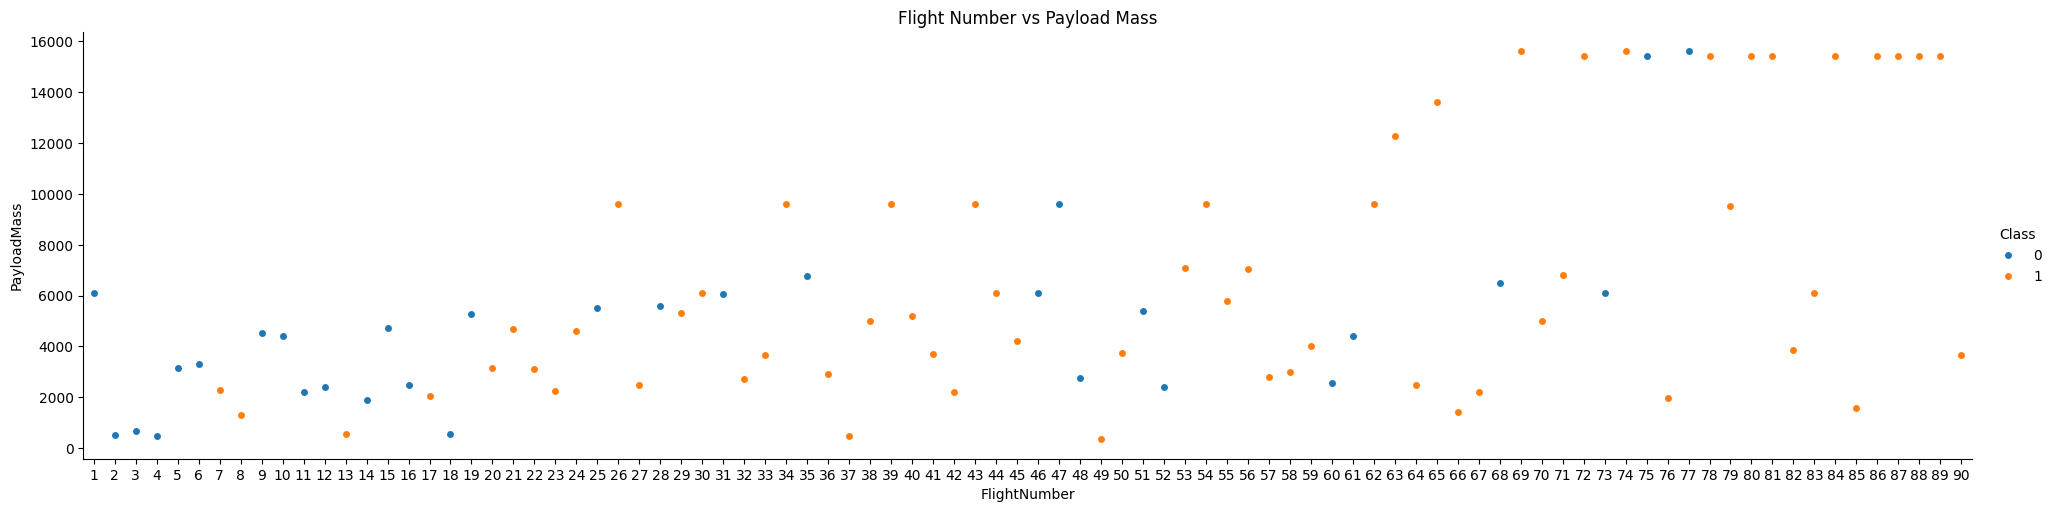

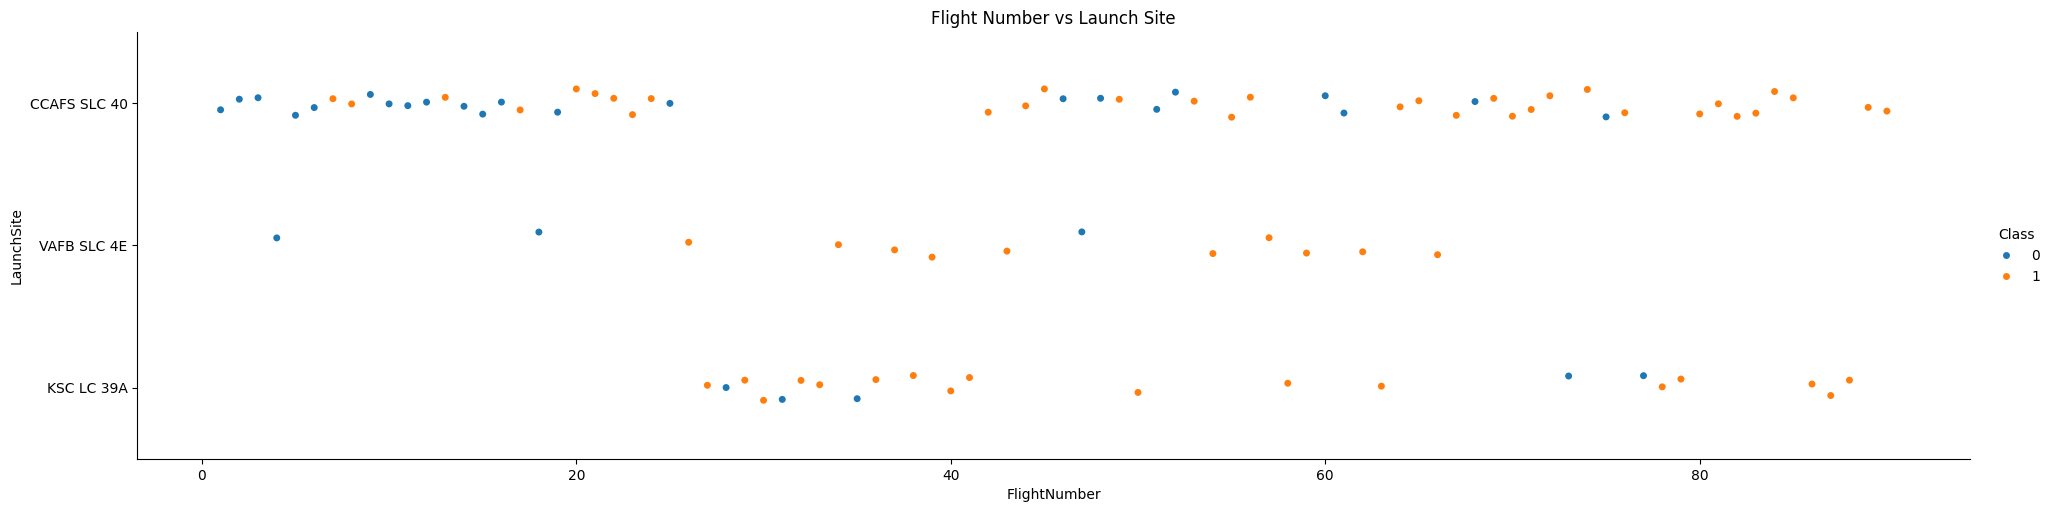

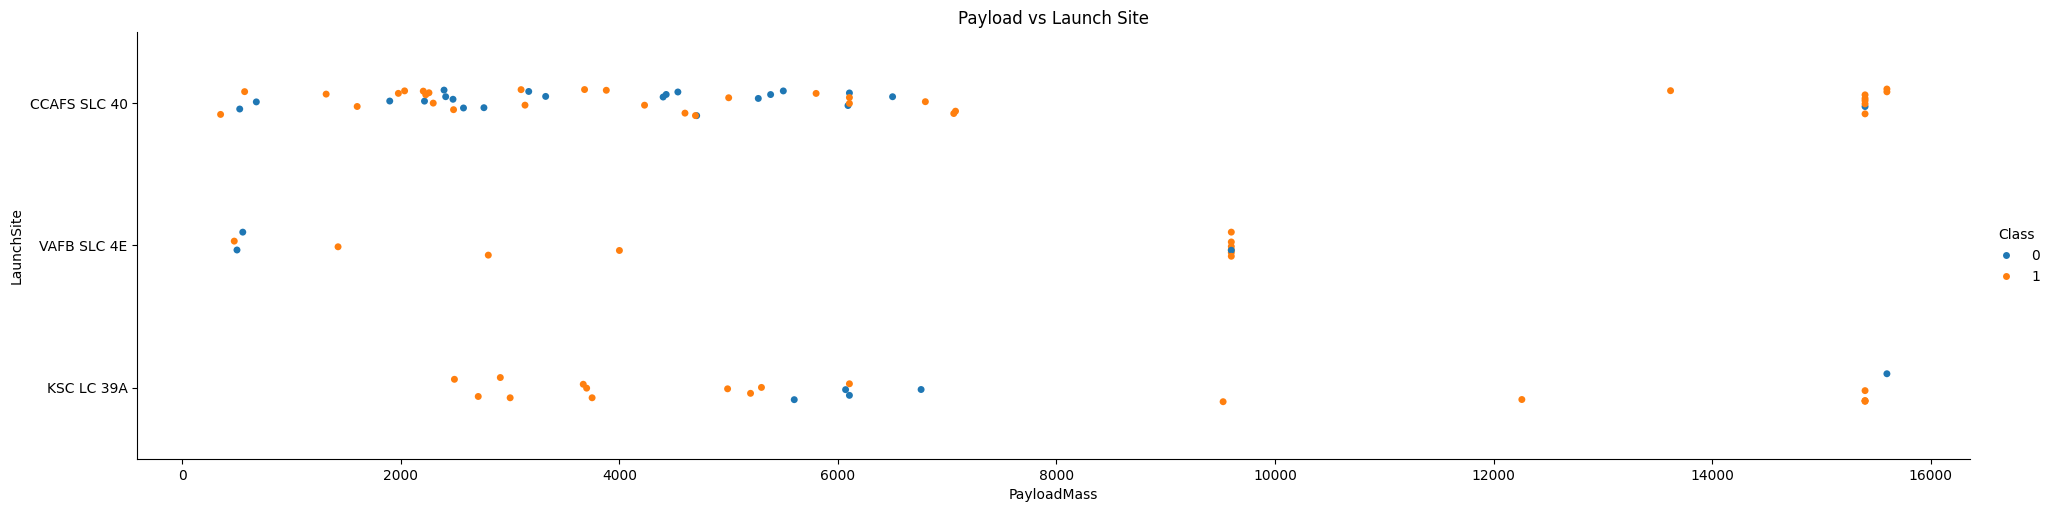

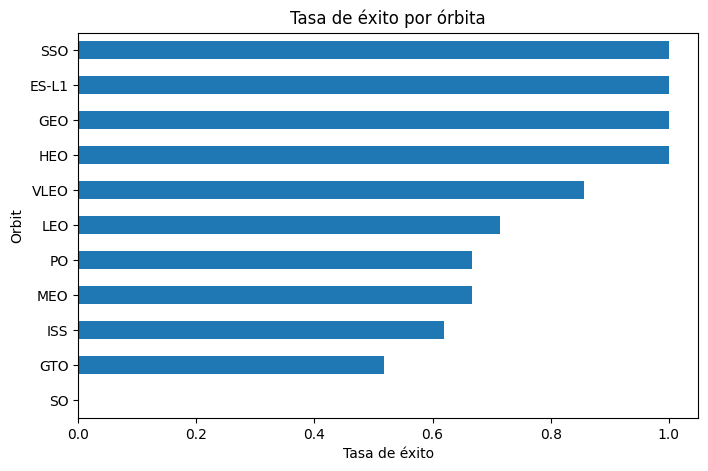

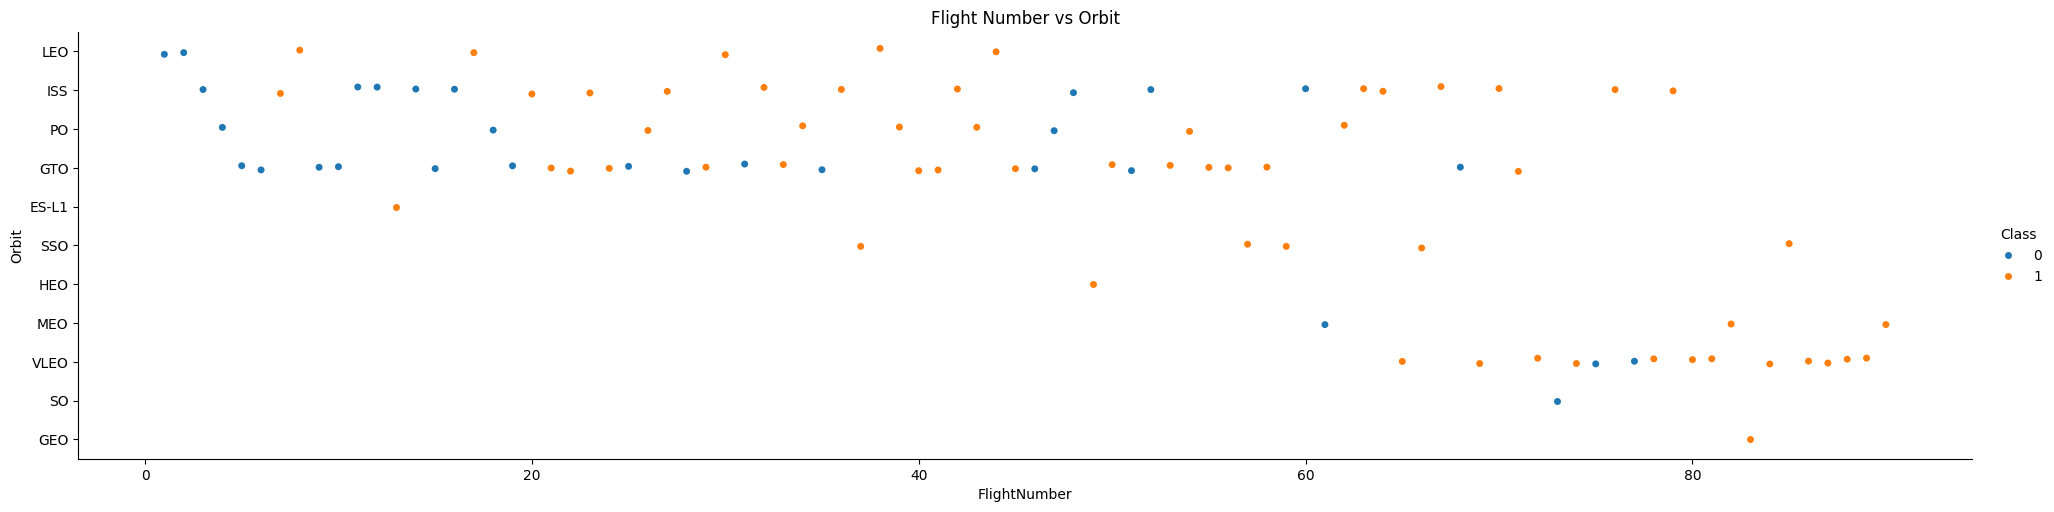

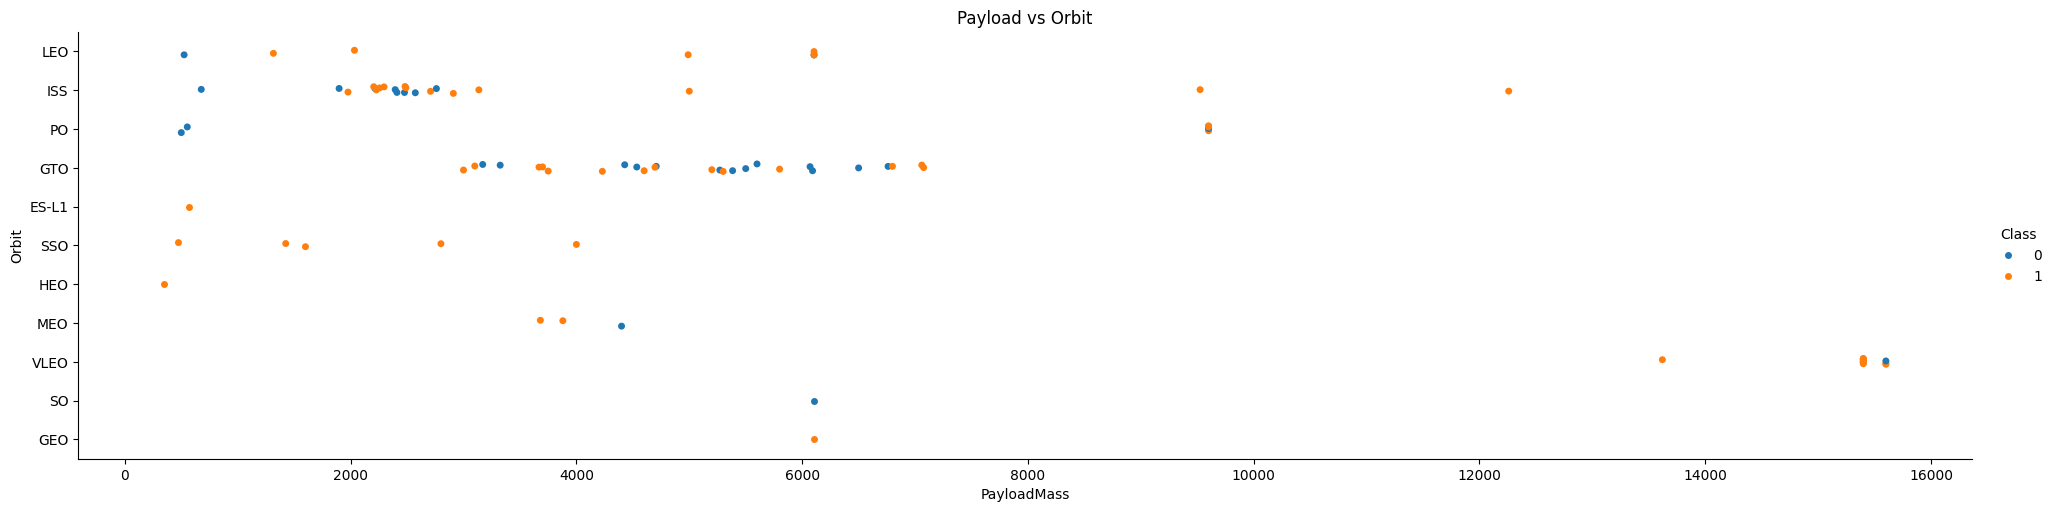

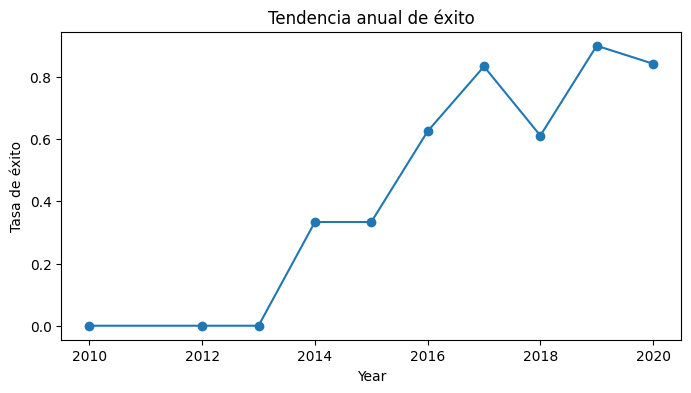

In [11]:
sns.catplot(y='PayloadMass', x='FlightNumber', hue='Class', data=df, aspect=4); plt.title('Flight Number vs Payload Mass'); plt.show()
sns.catplot(y='LaunchSite', x='FlightNumber', hue='Class', data=df, aspect=4); plt.title('Flight Number vs Launch Site'); plt.show()
sns.catplot(y='LaunchSite', x='PayloadMass', hue='Class', data=df, aspect=4); plt.title('Payload vs Launch Site'); plt.show()
df.groupby('Orbit')['Class'].mean().sort_values().plot(kind='barh', figsize=(8,5), title='Tasa de éxito por órbita'); plt.xlabel('Tasa de éxito'); plt.show()
sns.catplot(y='Orbit', x='FlightNumber', hue='Class', data=df, aspect=4); plt.title('Flight Number vs Orbit'); plt.show()
sns.catplot(y='Orbit', x='PayloadMass', hue='Class', data=df, aspect=4); plt.title('Payload vs Orbit'); plt.show()
df.groupby('Year')['Class'].mean().plot(marker='o', figsize=(8,4), title='Tendencia anual de éxito'); plt.ylabel('Tasa de éxito'); plt.show()

### Insights adicionales (punto de *innovación*)

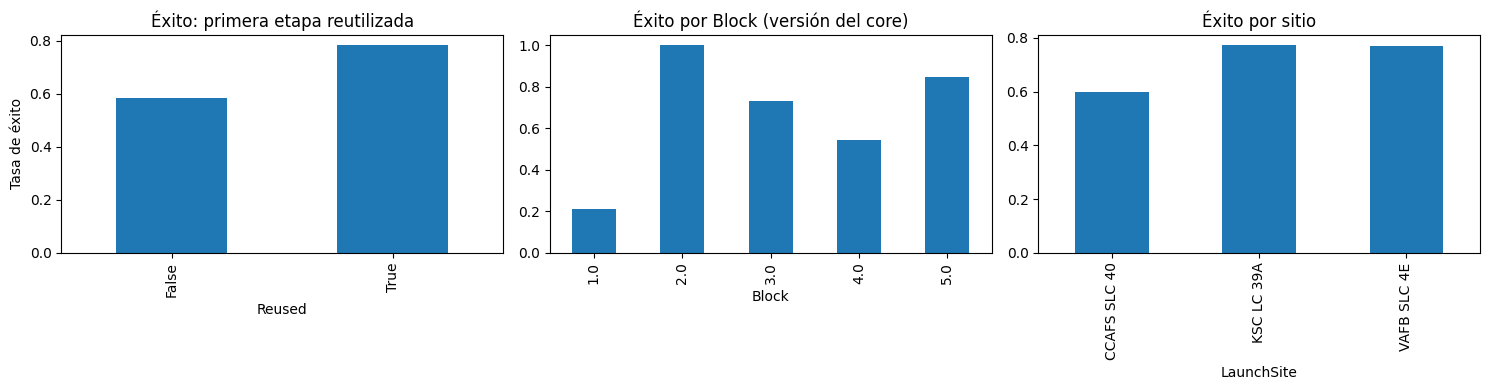

                mean  count
PayloadBin                 
(0, 2500]       0.61     23
(2500, 5000]    0.68     25
(5000, 7500]    0.47     19
(7500, 10000]   0.88      8
(10000, 20000]  0.87     15
Éxito primeros 30 vuelos: 43% → después del vuelo 60: 83%


In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
df.groupby('Reused')['Class'].mean().plot(kind='bar', ax=ax[0], title='Éxito: primera etapa reutilizada'); ax[0].set_ylabel('Tasa de éxito')
df.groupby('Block')['Class'].mean().plot(kind='bar', ax=ax[1], title='Éxito por Block (versión del core)')
df.groupby('LaunchSite')['Class'].mean().plot(kind='bar', ax=ax[2], title='Éxito por sitio'); plt.tight_layout(); plt.show()
df['PayloadBin'] = pd.cut(df['PayloadMass'], [0,2500,5000,7500,10000,20000])
print(df.groupby('PayloadBin', observed=True)['Class'].agg(['mean','count']).round(2))
early = df[df.FlightNumber<=30]['Class'].mean(); late = df[df.FlightNumber>60]['Class'].mean()
print(f'Éxito primeros 30 vuelos: {early:.0%} → después del vuelo 60: {late:.0%}')

## 4. EDA con SQL


In [13]:
import sqlite3
sp = pd.read_csv(BASE + 'labs/module_2/data/Spacex.csv')
sp.columns = [c.strip().replace(' ','_').replace('(','').replace(')','') for c in sp.columns]
print(sp.columns.tolist())
sp['Date'] = pd.to_datetime(sp['Date'], errors='coerce').dt.strftime('%Y-%m-%d')
con = sqlite3.connect(':memory:'); sp.to_sql('SPACEXTBL', con, index=False)
def q(sql):
    print(sql.strip()); return pd.read_sql(sql, con)
sp.head()

['Date', 'Time_UTC', 'Booster_Version', 'Launch_Site', 'Payload', 'PAYLOAD_MASS__KG_', 'Orbit', 'Customer', 'Mission_Outcome', 'Landing_Outcome']


,Date,Time_UTC,Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
0,2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
1,2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of...",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2,2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
3,2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
4,2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


In [24]:
display(q("SELECT DISTINCT Launch_Site FROM SPACEXTBL"))
display(q("SELECT * FROM SPACEXTBL WHERE Launch_Site LIKE 'CCA%' LIMIT 5"))
display(q("SELECT SUM(PAYLOAD_MASS__KG_) AS total_payload_nasa_crs FROM SPACEXTBL WHERE Customer LIKE '%NASA (CRS)%'"))
display(q("SELECT AVG(PAYLOAD_MASS__KG_) AS avg_payload_f9_v11 FROM SPACEXTBL WHERE Booster_Version LIKE 'F9 v1.1%'"))
display(q("SELECT MIN(Date) AS first_success_ground_pad FROM SPACEXTBL WHERE Landing_Outcome LIKE '%ground pad%' AND Landing_Outcome LIKE '%Success%'"))
display(q("SELECT DISTINCT Booster_Version FROM SPACEXTBL WHERE Landing_Outcome LIKE '%drone ship%' AND Landing_Outcome LIKE '%Success%' AND PAYLOAD_MASS__KG_ BETWEEN 4000 AND 6000"))
display(q("SELECT Mission_Outcome, COUNT(*) AS total FROM SPACEXTBL GROUP BY Mission_Outcome"))
display(q("SELECT DISTINCT Booster_Version FROM SPACEXTBL WHERE PAYLOAD_MASS__KG_ = (SELECT MAX(PAYLOAD_MASS__KG_) FROM SPACEXTBL)"))
display(q("SELECT substr(Date,6,2) AS month, Landing_Outcome, Booster_Version, Launch_Site FROM SPACEXTBL WHERE Landing_Outcome LIKE '%Failure%' AND Landing_Outcome LIKE '%drone%' AND substr(Date,1,4)='2015'"))
display(q("SELECT Landing_Outcome, COUNT(*) AS total FROM SPACEXTBL WHERE Date BETWEEN '2010-06-04' AND '2017-03-20' GROUP BY Landing_Outcome ORDER BY total DESC"))

SELECT DISTINCT Launch_Site FROM SPACEXTBL


,Launch_Site
0,CCAFS LC-40
1,VAFB SLC-4E
2,KSC LC-39A
3,CCAFS SLC-40


SELECT * FROM SPACEXTBL WHERE Launch_Site LIKE 'CCA%' LIMIT 5


,Date,Time_UTC,Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
0,2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
1,2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of...",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2,2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
3,2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
4,2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


SELECT SUM(PAYLOAD_MASS__KG_) AS total_payload_nasa_crs FROM SPACEXTBL WHERE Customer LIKE '%NASA (CRS)%'


...

,Booster_Version
0,F9 B5 B1048.4
1,F9 B5 B1049.4
2,F9 B5 B1051.3
3,F9 B5 B1056.4
4,F9 B5 B1048.5
5,F9 B5 B1051.4
6,F9 B5 B1049.5
7,F9 B5 B1060.2
8,F9 B5 B1058.3
9,F9 B5 B1051.6


SELECT substr(Date,6,2) AS month, Landing_Outcome, Booster_Version, Launch_Site FROM SPACEXTBL WHERE Landing_Outcome LIKE '%Failure%' AND Landing_Outcome LIKE '%drone%' AND substr(Date,1,4)='2015'


,month,Landing_Outcome,Booster_Version,Launch_Site
0,01,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
1,04,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40


SELECT Landing_Outcome, COUNT(*) AS total FROM SPACEXTBL WHERE Date BETWEEN '2010-06-04' AND '2017-03-20' GROUP BY Landing_Outcome ORDER BY total DESC


,Landing_Outcome,total
0,No attempt,10
1,Success (drone ship),5
2,Failure (drone ship),5
3,Success (ground pad),3
4,Controlled (ocean),3
5,Uncontrolled (ocean),2
6,Failure (parachute),2
7,Precluded (drone ship),1


## 5. Mapa interactivo con Folium


In [31]:
import folium
from folium.plugins import MarkerCluster, MousePosition
from math import radians, sin, cos, sqrt, atan2

geo = pd.read_csv(BASE + 'datasets/spacex_launch_geo.csv')
sites = geo.groupby('Launch Site')[['Lat','Long']].first().reset_index()

SAT = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'

def new_map(location, zoom):
    m = folium.Map(location=location, zoom_start=zoom, tiles='CartoDB positron')   # mapa base sin bloqueo
    folium.TileLayer(SAT, attr='Esri World Imagery', name='Satélite').add_to(m)    # útil para medir distancias
    folium.LayerControl().add_to(m)
    return m

m = new_map([29.56, -95.08], 4)
for _, r in sites.iterrows():
    folium.Circle([r.Lat, r.Long], radius=1000, color='#d35400', fill=True).add_to(m)
    folium.Marker([r.Lat, r.Long],
        icon=folium.DivIcon(html=f'<b style="color:#d35400;white-space:nowrap">{r["Launch Site"]}</b>')).add_to(m)
m

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning:

CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.



In [35]:
geo['color'] = geo['class'].map({1: 'green', 0: 'red'})
m2 = new_map([28.5, -80.6], 5)
mc = MarkerCluster().add_to(m2)
for _, r in geo.iterrows():
    folium.Marker([r.Lat, r.Long],
        icon=folium.Icon(color='white', icon_color=r.color), popup=r['Launch Site']).add_to(mc)
m2

In [30]:
def dist_km(a, b):
    R = 6373.0
    la1, lo1, la2, lo2 = map(radians, [a[0], a[1], b[0], b[1]])
    h = sin((la2-la1)/2)**2 + cos(la1)*cos(la2)*sin((lo2-lo1)/2)**2
    return R * 2 * atan2(sqrt(h), sqrt(1-h))

site  = (28.563197, -80.576820)   # CCAFS SLC-40
coast = (28.56367, -80.57163)     # EJEMPLO: reemplaza con la coordenada que midas en tu mapa
d = dist_km(site, coast); print(f'Distancia a la costa: {d:.2f} km')

m3 = new_map(site, 14)
MousePosition().add_to(m3)
folium.Marker(site, popup='CCAFS SLC-40').add_to(m3)
folium.Marker(coast, icon=folium.DivIcon(html=f'<b style="white-space:nowrap">{d:.2f} KM</b>')).add_to(m3)
folium.PolyLine([site, coast], weight=2, color='red').add_to(m3)
m3

Distancia a la costa: 0.51 km


## 6. Dashboard con Plotly Dash (inline)


In [36]:
import plotly.express as px
from dash import Dash, dcc, html, Input, Output
dd = pd.read_csv(BASE + 'datasets/spacex_launch_dash.csv')
opts = [{'label':'All Sites','value':'ALL'}] + [{'label':s,'value':s} for s in dd['Launch Site'].unique()]
app = Dash(__name__)
app.layout = html.Div([
    html.H1('SpaceX Launch Records Dashboard'),
    dcc.Dropdown(id='site', options=opts, value='ALL', searchable=True),
    dcc.Graph(id='pie'),
    html.P('Payload range (kg):'),
    dcc.RangeSlider(id='pay', min=0, max=10000, step=1000, value=[dd['Payload Mass (kg)'].min(), dd['Payload Mass (kg)'].max()]),
    dcc.Graph(id='scatter')])
@app.callback(Output('pie','figure'), Input('site','value'))
def pie(s):
    if s == 'ALL': return px.pie(dd[dd['class']==1], names='Launch Site', title='Lanzamientos exitosos por sitio')
    return px.pie(dd[dd['Launch Site']==s], names='class', title=f'Éxito vs fracaso – {s}')
@app.callback(Output('scatter','figure'), [Input('site','value'), Input('pay','value')])
def scat(s, p):
    d = dd[dd['Payload Mass (kg)'].between(p[0], p[1])]
    if s != 'ALL': d = d[d['Launch Site']==s]
    return px.scatter(d, x='Payload Mass (kg)', y='class', color='Booster Version Category', title='Payload vs resultado')
app.run(jupyter_mode='inline', port=8050)

<IPython.core.display.Javascript object>

## 7. Modelos de clasificación


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

feat = df[['FlightNumber','PayloadMass','Orbit','LaunchSite','Flights','GridFins','Reused','Legs','LandingPad','Block','ReusedCount','Serial']].copy()
feat['Block'] = feat['Block'].fillna(feat['Block'].median()); feat['ReusedCount'] = feat['ReusedCount'].fillna(0)
X = pd.get_dummies(feat, columns=['Orbit','LaunchSite','LandingPad','Serial']).astype(float)
Y = df['Class'].to_numpy()
print('Features:', X.shape[1], '| muestras:', len(Y))
Xs = StandardScaler().fit_transform(X)
Xtr, Xte, ytr, yte = train_test_split(Xs, Y, test_size=0.2, random_state=2)
print('Train:', Xtr.shape, '| Test:', Xte.shape)

Features: 80 | muestras: 90
Train: (72, 80) | Test: (18, 80)


In [21]:
grids = {
 'Logistic Regression': (LogisticRegression(max_iter=1000), {'C':[0.01,0.1,1], 'penalty':['l2'], 'solver':['lbfgs']}),
 'SVM': (SVC(), {'kernel':['linear','rbf','poly','sigmoid'], 'C':np.logspace(-3,3,5), 'gamma':np.logspace(-3,3,5)}),
 'Decision Tree': (DecisionTreeClassifier(random_state=2), {'criterion':['gini','entropy'], 'max_depth':[2*n for n in range(1,10)],
                   'max_features':['sqrt','log2'], 'min_samples_leaf':[1,2,4], 'min_samples_split':[2,5,10]}),
 'KNN': (KNeighborsClassifier(), {'n_neighbors':list(range(1,11)), 'algorithm':['auto','ball_tree','kd_tree','brute'], 'p':[1,2]})}
res, best = {}, {}
for name,(mdl,g) in grids.items():
    gs = GridSearchCV(mdl, g, cv=10).fit(Xtr, ytr)
    res[name] = {'CV accuracy':round(gs.best_score_,4), 'Test accuracy':round(gs.score(Xte,yte),4), 'Mejores parámetros':gs.best_params_}
    best[name] = gs
results = pd.DataFrame(res).T
results

,CV accuracy,Test accuracy,Mejores parámetros
Logistic Regression,0.8214,0.8333,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}"
SVM,0.8482,0.8333,"{'C': 1.0, 'gamma': 0.03162277660168379, 'kern..."
Decision Tree,0.8179,0.8333,"{'criterion': 'entropy', 'max_depth': 4, 'max_..."
KNN,0.8339,0.8333,"{'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}"


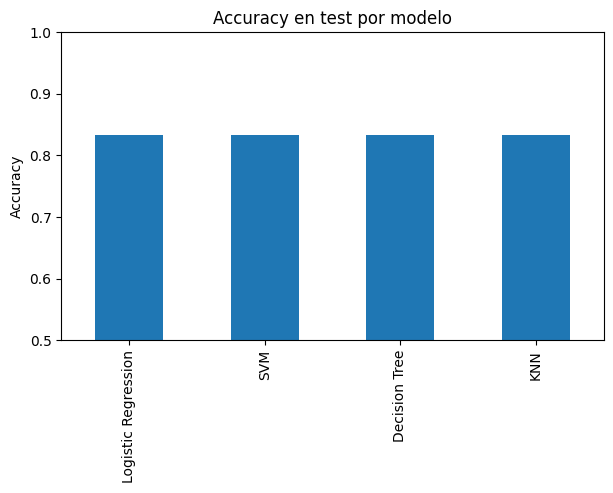

Mejor modelo: Logistic Regression


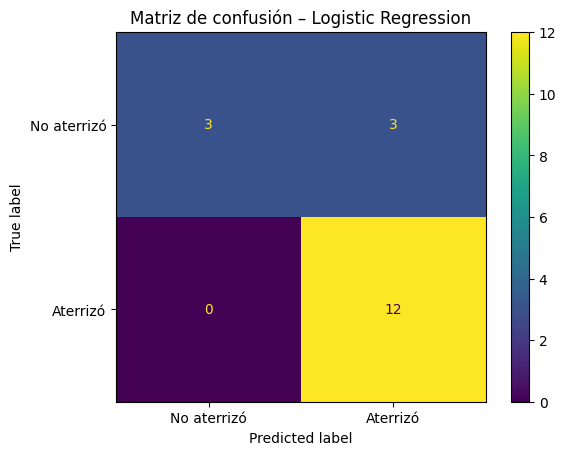

In [22]:
results['Test accuracy'].astype(float).plot(kind='bar', ylim=(0.5,1), figsize=(7,4), title='Accuracy en test por modelo'); plt.ylabel('Accuracy'); plt.show()
top = results['Test accuracy'].astype(float).idxmax(); print('Mejor modelo:', top)
ConfusionMatrixDisplay(confusion_matrix(yte, best[top].predict(Xte)), display_labels=['No aterrizó','Aterrizó']).plot()
plt.title(f'Matriz de confusión – {top}'); plt.show()

## 8. Resumen para *Executive Summary* y *Conclusión*

In [23]:
yr = df.groupby('Year')['Class'].mean()
print(f'Registros: {len(df)} | tasa global de éxito: {df.Class.mean():.1%}')
print(f'Éxito {yr.index[0]}: {yr.iloc[0]:.0%}  →  {yr.index[-1]}: {yr.iloc[-1]:.0%}')
print('Órbitas con 100% de éxito:', df.groupby('Orbit').Class.mean().loc[lambda s: s==1].index.tolist())
print('Sitio con mayor éxito:', df.groupby('LaunchSite').Class.mean().idxmax())
print('Mejor modelo:', top, '| Test accuracy:', results.loc[top,'Test accuracy'])
print('Fuente de datos de recolección:', SOURCE)

Registros: 90 | tasa global de éxito: 66.7%
Éxito 2010: 0%  →  2020: 84%
Órbitas con 100% de éxito: ['ES-L1', 'GEO', 'HEO', 'SSO']
Sitio con mayor éxito: KSC LC 39A
Mejor modelo: Logistic Regression | Test accuracy: 0.8333
Fuente de datos de recolección: dataset_part_1.csv del lab
